In [2]:
%load_ext autoreload
%autoreload 2

# 1. Import CellRefiner and packages

In [3]:
import numpy as np
import pandas as pd
import squidpy as sq
import seaborn as sns
from matplotlib import pyplot as plt
import scanpy as sc

/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [4]:
import sys
sys.path.append('..')
import cellrefiner as cr

# 2. Load Data

The paired datasets here are from Visium spatial transcriptomic data and scRNA-seq samples of the mouse cortex available via the squidpy package.

In [25]:
adata_st = sc.read_h5ad(f'Mouse_Kidney_ST.h5ad')
adata_sc = sc.read_h5ad(f'Mouse_Kidney_SC.h5ad')
cluster_key_st = 'leiden'
cluster_key_sc = 'cell_name'
spatial_key = 'spatial'
# remove isolated spots
sq.gr.spatial_neighbors(adata_st)
mean_d = np.zeros(adata_st.shape[0])
indptr = adata_st.obsp['spatial_distances'].indptr
d = adata_st.obsp['spatial_distances'].data
for i in range(adata_st.shape[0]):
    mean_d[i] = d[indptr[i]:indptr[i+1]].mean()
I = ~np.isnan(mean_d)
adata_st = adata_st[I]
print('SC:\n',adata_sc)
print('ST:\n',adata_st)

# adata_st = sq.datasets.visium_fluo_adata_crop()
# adata_st = adata_st[adata_st.obs.cluster.isin([f"Cortex_{i}" for i in np.arange(1, 5)])].copy()
# adata_sc = sq.datasets.sc_mouse_cortex()
# adata_sc0 = adata_sc.copy()
# print(adata_st)
# print(adata_sc)

SC:
 AnnData object with n_obs × n_vars = 10727 × 49584
    obs: 'source', 'replicate', 'experiment', 'cell_name'
    var: 'gene_id', 'gene_type'
    uns: 'cell_name_colors', 'experiment_colors', 'log1p', 'neighbors', 'pca', 'replicate_colors', 'source_colors', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
ST:
 View of AnnData object with n_obs × n_vars = 1431 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'spatial', 'spatial_neighbors'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'


/tmp/ipykernel_3945368/799816073.py:13: RuntimeWarning: Mean of empty slice.
  mean_d[i] = d[indptr[i]:indptr[i+1]].mean()
/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Load the mouse ligand-receptor database from local path, originally sourced from CellChat

In [26]:
db = pd.read_csv(R'LR.csv')
slide_key = list(adata_st.uns['spatial'].keys())
scale = adata_st.uns['spatial'][slide_key[0]]['scalefactors']['spot_diameter_fullres']
adata_cr = cr.pp.spatial_mapping(adata_st,adata_sc,db,scale=scale,cluster_key_sc = cluster_key_sc)
print(adata_cr)

/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 7155 × 991
    obs: 'source', 'replicate', 'experiment', 'cell_name'
    var: 'gene_id', 'gene_type'
    uns: 'cell_name_colors', 'experiment_colors', 'log1p', 'neighbors', 'pca', 'replicate_colors', 'source_colors', 'umap', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


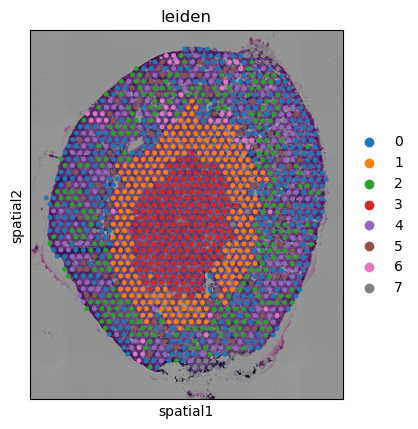

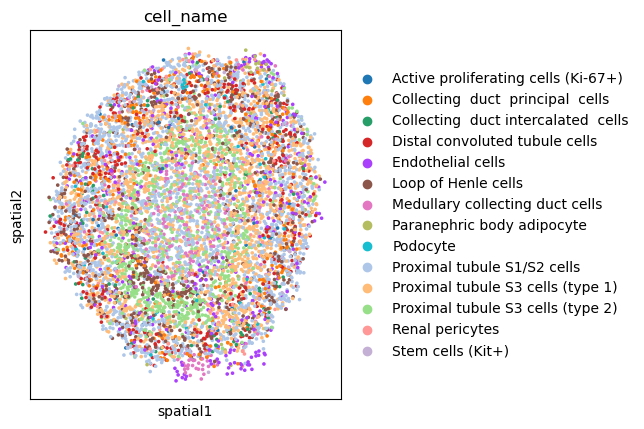

In [28]:
sc.pl.spatial(adata_st, color = cluster_key_st)
sc.pl.spatial(adata_cr, color = cluster_key_sc,spot_size = 70)

In [29]:
sem = cr.tl.cell_shape_modeling(adata_cr,cluster_key = cluster_key_sc)

Simulation: 100%|██████████| 2000/2000 [06:28<00:00,  5.15it/s]


add .obsp['contacts'], .uns['contacts']
Computing alpha-shape with parameters: alpha=None, ns=10, r=1.2


Processing Cell Shapes: 100%|██████████| 7155/7155 [01:09<00:00, 102.23it/s]


<Axes: >

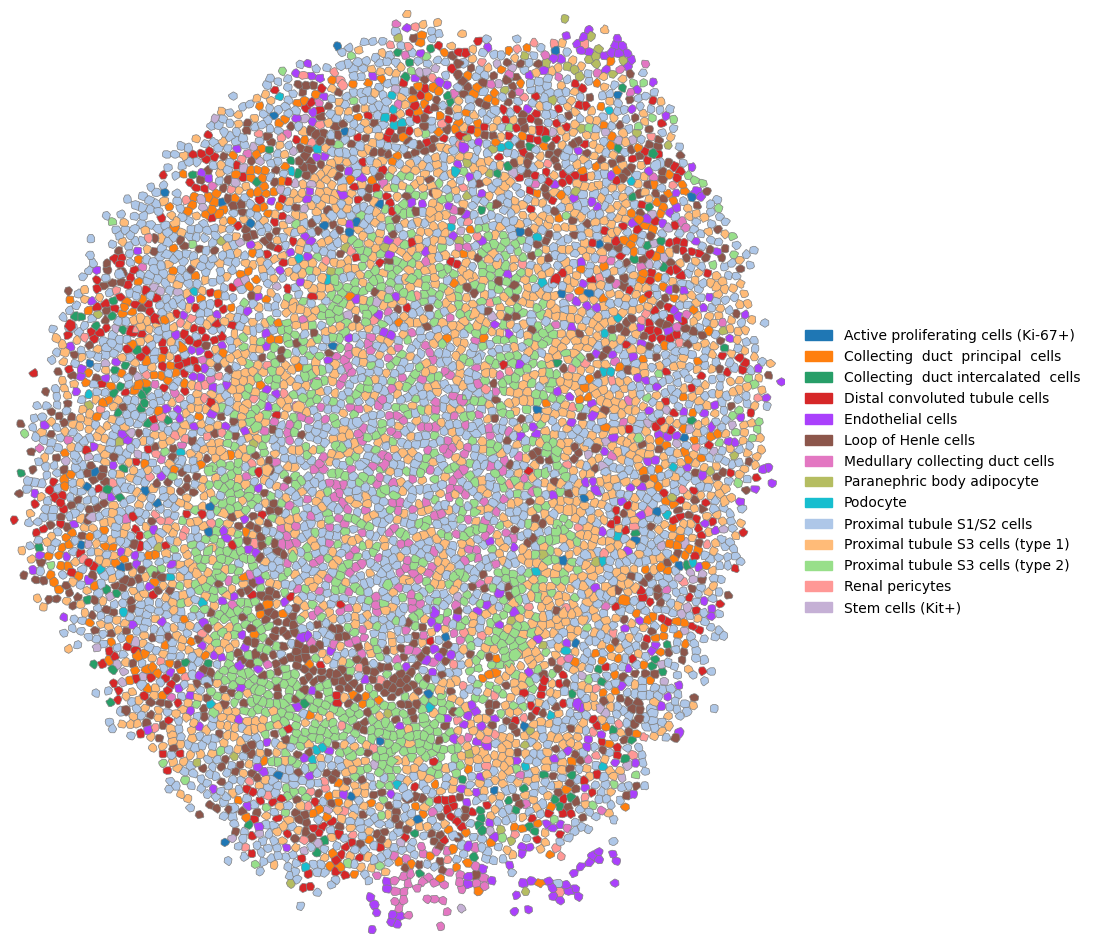

In [30]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,boundary_color='gray',boundary_width=0.5)

In [31]:
db_lr = cr.pp.ligand_receptor_database()
db_lr = cr.pp.filter_lr_database(db_lr,adata_cr, min_cell_pct=0.01)
cr.tl.contact_communication(db_lr, adata = adata_cr)

add .uns['contact_signal_info']
add .obsm['sender_signal'], .obsm['receiver_signal']


In [ ]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,vis_key='NOTCH',boundary_color='gray',boundary_width=0.1)
cr.pl.plot_contact_signal(sem,ax=ax,signal = 'NOTCH')

In [ ]:
cr.tl.cluster_communication(adata_cr,cluster_key = cluster_key_sc,signal = 'NOTCH')
fig,ax=plt.subplots(figsize=(6,4))
sns.heatmap(adata_cr.uns[f'{cluster_key_sc}-NOTCH']['communication_pvalue']<0.05,square=True,linewidths=1,ax=ax,cmap='Reds',cbar=False)